In [5]:

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

from arch import arch_model
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import het_arch

# Getting data 

In [7]:

# df should contain a price column, for example 'Adj Close'
df = HDFC.copy()
price_col = 'Adj Close'   # change if your column name is different

df['simple_return'] = df[price_col].pct_change()
df['log_return'] = np.log(df[price_col] / df[price_col].shift(1))

# clean output for modeling
returns = df[['simple_return', 'log_return']].dropna()

print(returns.head())
print("\nSimple return summary:")
print(returns['simple_return'].describe())
print("\nLog return summary:")
print(returns['log_return'].describe())

NameError: name 'df' is not defined

In [31]:
ALL_Data =  pd.read_csv("All_features.csv",index_col="Date",parse_dates=["Date"]).dropna()
HDFC = ALL_Data["HDFCBANK"].to_frame()
HDFC

,HDFCBANK
Date,
2015-01-05,500.999146
2015-01-06,483.090759
2015-01-07,482.703583
2015-01-08,485.898041
2015-01-09,479.121918
...,...
2025-12-22,1233.199951
2025-12-23,1225.000000
2025-12-24,1226.300049


In [33]:
HDFC ['simple_return'] = HDFC["HDFCBANK"].pct_change()
HDFC['log_return'] = np.log(HDFC["HDFCBANK"]/ HDFC["HDFCBANK"].shift(1))


# EDA

In [37]:
HDFC.dropna(inplace = True)

In [51]:
HDFC.isna().sum()
HDFC.duplicated().sum()

1

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.diagnostic import het_arch

In [69]:
# Example: if your dataframe already exists, skip this
# df = pd.read_csv("your_file.csv")

HDFC.head()

,HDFCBANK,simple_return,log_return
Date,,,
2015-01-06,483.090759,-0.035745,-0.036400
2015-01-07,482.703583,-0.000801,-0.000802
2015-01-08,485.898041,0.006618,0.006596
2015-01-09,479.121918,-0.013946,-0.014044
2015-01-13,488.366577,0.019295,0.019111


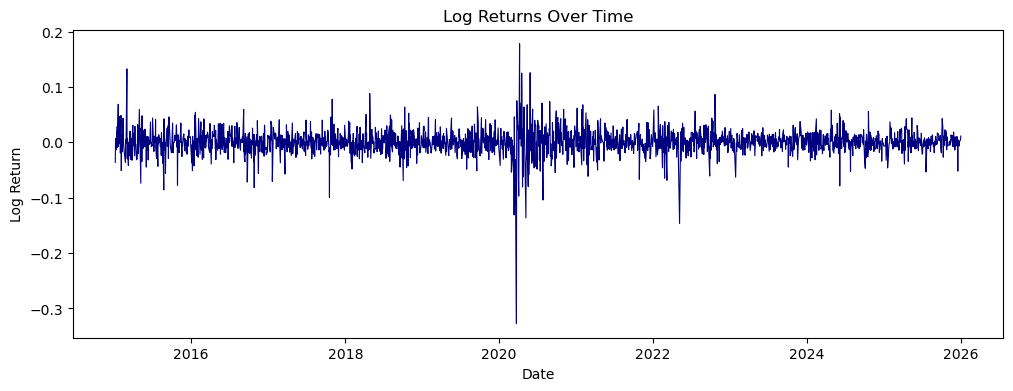

In [75]:
plt.figure(figsize=(12,4))
plt.plot(HDFC.index, HDFC['log_return'], color='navy', linewidth=0.8)
plt.title('Log Returns Over Time')
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.show()

# What you get: return movement over time.
# Why we use it: to see volatility clustering, where calm periods and turbulent periods appear together.



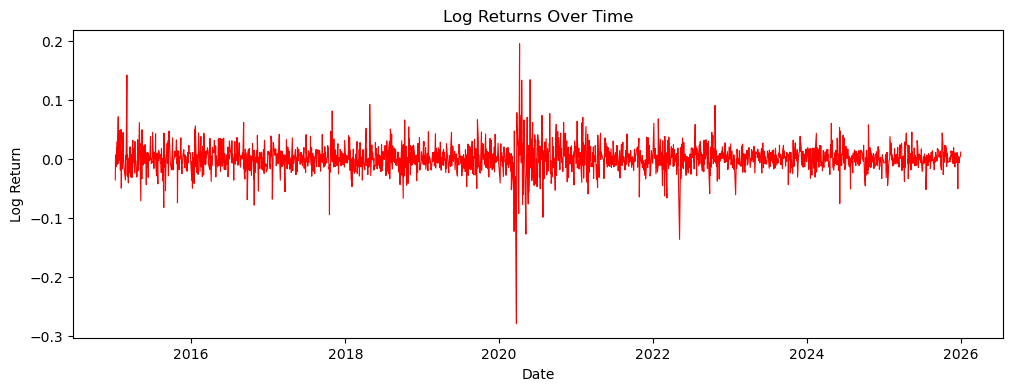

In [79]:
plt.figure(figsize=(12,4))
plt.plot(HDFC.index, HDFC['simple_return'], color='red', linewidth=0.8)
plt.title('Log Returns Over Time')
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.show()

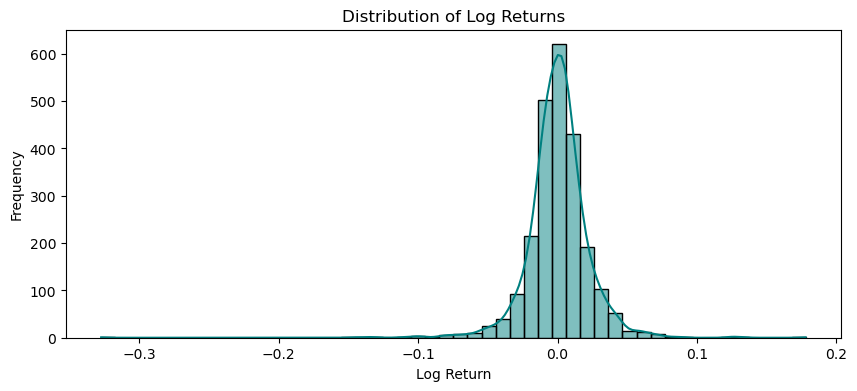

In [83]:
plt.figure(figsize=(10,4))
sns.histplot(HDFC['log_return'], bins=50, kde=True, color='teal')
plt.title('Distribution of Log Returns')
plt.xlabel('Log Return')
plt.ylabel('Frequency')
plt.show()

# What you get: shape of return distribution.
# Why we use it: to check skewness, fat tails, and non-normality.



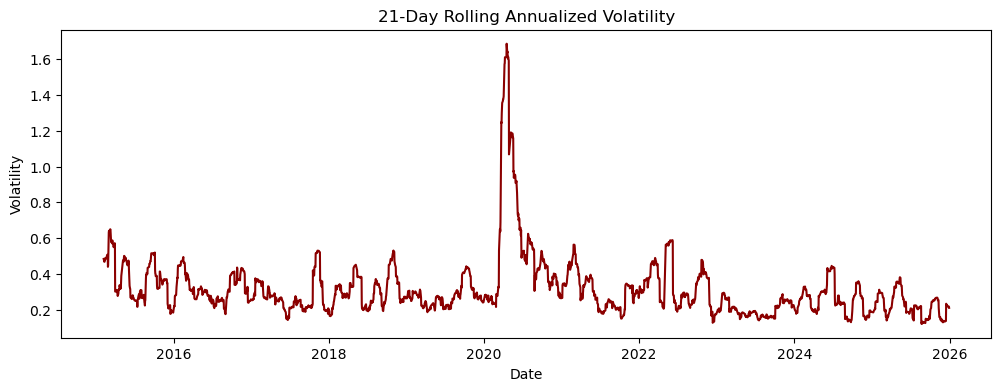

In [87]:
window = 21
HDFC['rolling_vol'] = HDFC['log_return'].rolling(window).std() * np.sqrt(252)

plt.figure(figsize=(12,4))
plt.plot(HDFC.index, HDFC['rolling_vol'], color='darkred')
plt.title(f'{window}-Day Rolling Annualized Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.show()

# What you get: time-varying volatility estimate.
# Why we use it: volatility is not constant, and ARCH/GARCH models are built to capture this.

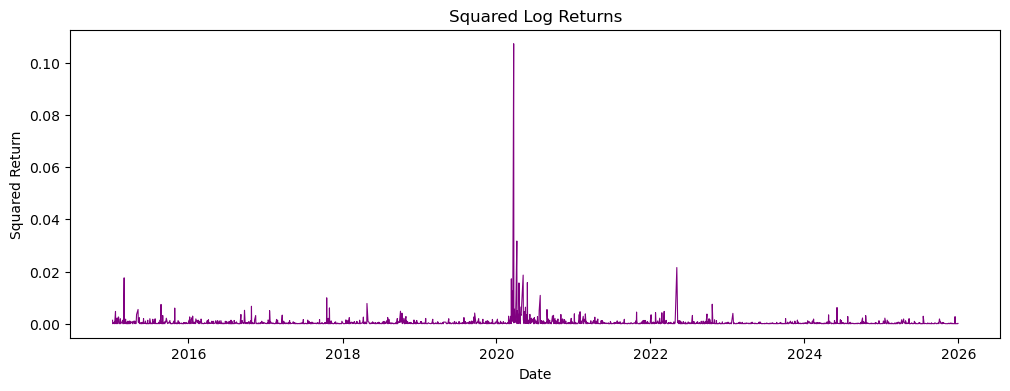

In [93]:
HDFC['squared_return'] = HDFC['log_return']**2

plt.figure(figsize=(12,4))
plt.plot(HDFC.index, HDFC['squared_return'], color='purple', linewidth=0.8)
plt.title('Squared Log Returns')
plt.xlabel('Date')
plt.ylabel('Squared Return')
plt.show()

# What you get: spikes in volatility intensity.
# Why we use it: ARCH models are based on the idea that current variance depends on past squared shocks

<Figure size 1000x400 with 0 Axes>

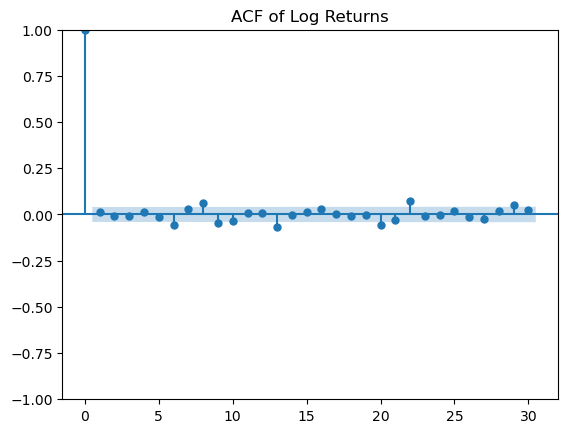

In [95]:
plt.figure(figsize=(10,4))
plot_acf(HDFC['log_return'], lags=30)
plt.title('ACF of Log Returns')
plt.show

# What you get: autocorrelation in returns.
# Why we use it: usually raw returns have weak autocorrelation, but this helps confirm it before volatility modeling.

<Figure size 1000x400 with 0 Axes>

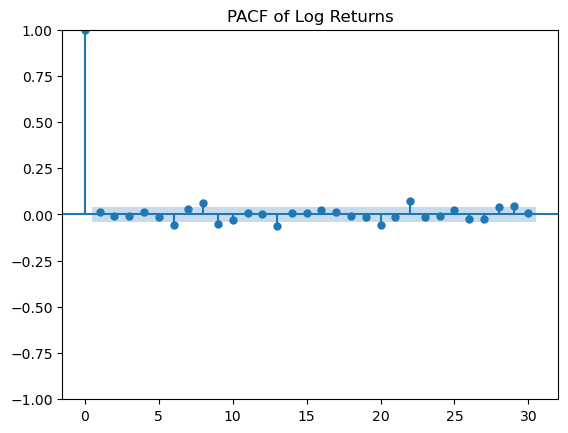

In [97]:
plt.figure(figsize=(10,4))
plot_pacf(HDFC['log_return'], lags=30, method='ywm')
plt.title('PACF of Log Returns')
plt.show()

# What you get: partial autocorrelation structure.
# Why we use it: helps check whether a mean model is needed before volatility modeling.

<Figure size 1000x400 with 0 Axes>

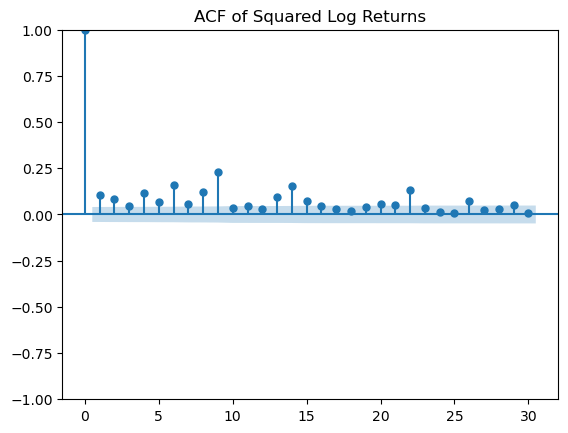

In [99]:
plt.figure(figsize=(10,4))
plot_acf(HDFC['squared_return'], lags=30)
plt.title('ACF of Squared Log Returns')
plt.show()

# What you get: persistence in volatility.
# Why we use it: if squared returns are autocorrelated, that is strong evidence for ARCH effects.

<Figure size 600x600 with 0 Axes>

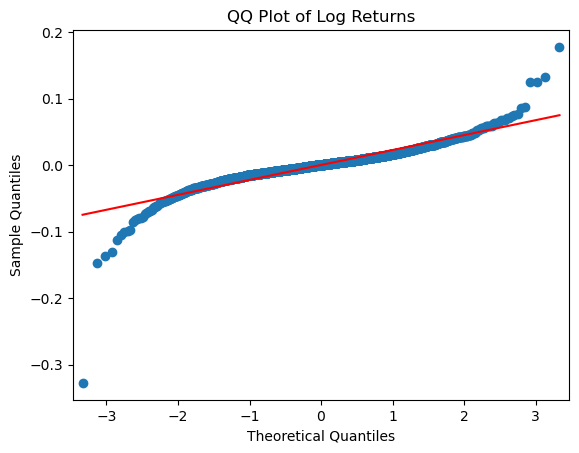

In [101]:
plt.figure(figsize=(6,6))
qqplot(HDFC['log_return'], line='s')
plt.title('QQ Plot of Log Returns')
plt.show()

# What you get: comparison of your return distribution to normal distribution.
# Why we use it: financial returns often have heavy tails, so normality usually fails.

In [103]:
print(HDFC['log_return'].describe())
print("\nSkewness:", HDFC['log_return'].skew())
print("Kurtosis:", HDFC['log_return'].kurtosis())

# What you get: summary stats, skewness, and kurtosis.
# Why we use it: high kurtosis means fat tails, which is common in financial data and important for risk modeling.

count    2341.000000
mean        0.000389
std         0.022461
min        -0.327499
25%        -0.009772
50%         0.000693
75%         0.010756
max         0.177985
Name: log_return, dtype: float64

Skewness: -1.3758176355654832
Kurtosis: 25.287099045064316


In [109]:
arch_test = het_arch(HDFC['log_return'])
print("ARCH test statistic:", arch_test[0])
print("ARCH test p-value:", arch_test[1])

# What you get: formal test for ARCH effect.
# Why we use it: if p-value is small, volatility clustering is present and ARCH/GARCH is justified.

ARCH test statistic: 221.75279513058578
ARCH test p-value: 4.5914056165897837e-42
